In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator, QiskitRuntimeService
 
QiskitRuntimeService.save_account(
token="ezWDWhMPkm4EKsFC8iq2dvRIWPe4H8-e3IIm0oVx_3ba", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/df0456804203486e9cb63132d6fe45ec:bcbc0e1e-a0e7-42e3-b260-4b8f9d934c86::", # Optional
overwrite=True
)

# Create a new circuit with two qubits
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
 
qc.draw("mpl")

# Set up six different observables.
 
observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]


 
service = QiskitRuntimeService()
 
backend = service.least_busy(simulator=False, operational=True)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

# Construct the Estimator instance.
 
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000
 
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

QiskitRuntimeService.save_account(
token="ezWDWhMPkm4EKsFC8iq2dvRIWPe4H8-e3IIm0oVx_3ba", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/df0456804203486e9cb63132d6fe45ec:bcbc0e1e-a0e7-42e3-b260-4b8f9d934c86::", # Optional
overwrite=True
)

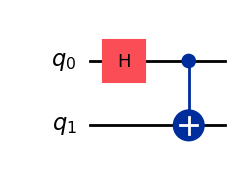

In [3]:


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.draw("mpl")



In [5]:
# Measure the classical bits by appending measurements to the circuit
qc_with_measure = qc.copy()
qc_with_measure.measure_all()

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)

# Transpile (layout map) for backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc_with_measure)

isa_circuit.draw("mpl", idle_wires=False)

# Construct the Sampler instance.
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1000

# Run the circuit and sample results (measuring all classical bits)
job = sampler.run([isa_circuit])

print(f">>> Job ID: {job.job_id()}")

# Wait for job to complete and retrieve result
job_result = job.result()

# Get the quasi-probabilities/distribution result from our run
counts = job_result[0].data.bin_counts
print("Measured classical bit distribution:", counts)

>>> Job ID: d5ju234jt3vs73drple0


AttributeError: 'DataBin' object has no attribute 'bin_counts'

In [18]:
results = job_result[0].data.meas.get_bitstrings()
resultsdict = {s: results.count(s) for s in set(results)}
print(resultsdict)

{'00': 472, '11': 464, '01': 24, '10': 40}


In [24]:
from tqdm import tqdm

In [37]:
numiterations = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
numshots = 1000
resultslist = []

for ni in tqdm(numiterations):
    # Create a circuit with single qubit
    qc = QuantumCircuit(1)
    #qc.x(0) # Prepare the qubit in the 1 state
    for n in range(ni):
        qc.id(0) # Apply idle gates to allow noise to accumulate

    # Measure the classical bits by appending measurements to the circuit
    qc.measure_all()

    service = QiskitRuntimeService()
    backend = service.least_busy(simulator=False, operational=True)

    # Transpile (layout map) for backend
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    isa_circuit = pm.run(qc)

    # Construct the Sampler instance.
    sampler = Sampler(mode=backend)
    sampler.options.default_shots = numshots

    # Run the circuit and sample results (measuring all classical bits)
    job = sampler.run([isa_circuit])

    print(f">>> Job ID: {job.job_id()}")

    # Wait for job to complete and retrieve result
    job_result = job.result()

    results = job_result[0].data.meas.get_bitstrings()
    resultsdict = {s: results.count(s) for s in set(results)}
    resultslist.append(resultsdict)


  0%|          | 0/10 [00:00<?, ?it/s]

>>> Job ID: d5jv1iqvcahs73a1c0r0


 10%|█         | 1/10 [00:10<01:33, 10.36s/it]

>>> Job ID: d5jv1lkjt3vs73drqrs0


 20%|██        | 2/10 [00:22<01:30, 11.28s/it]

...

 80%|████████  | 8/10 [01:28<00:22, 11.08s/it]

>>> Job ID: d5jv28sjt3vs73drqsf0


 90%|█████████ | 9/10 [01:38<00:10, 10.84s/it]

>>> Job ID: d5jv2bv853es738d8jr0


100%|██████████| 10/10 [03:33<00:00, 21.32s/it]


In [35]:
resultslist1 = resultslist

In [ ]:
print(resultslist1)

[{'1': 972, '0': 28}, {'1': 974, '0': 26}, {'1': 969, '0': 31}, {'1': 968, '0': 32}, {'1': 964, '0': 36}, {'1': 936, '0': 64}, {'1': 932, '0': 68}, {'1': 897, '0': 103}, {'1': 772, '0': 228}, {'1': 614, '0': 386}]
